In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

projekt = "/content/drive/MyDrive/magisterka_wig20"
os.makedirs(projekt, exist_ok=True)

print(projekt)

/content/drive/MyDrive/magisterka_wig20


In [ ]:
sciezka = "/content/drive/MyDrive/magisterka_wig20"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt





In [ ]:
import pandas as pd

wig20 = pd.read_csv(f"{sciezka}/wig20.csv")
inflacja = pd.read_csv(f"{sciezka}/inflacja.csv")
vix = pd.read_csv(f"{sciezka}/vix.csv")

finalny_dataset = pd.read_csv(f"{sciezka}/finalny_dataset.csv")

wyniki_modeli = pd.read_csv(f"{sciezka}/wyniki_modeli.csv")

In [ ]:
wig20 = pd.read_csv("wig20.csv")

wig20.head()

,Date,Open,High,Low,Close,Volume
0,2010-01-04,2403.01,2450.63,2403.01,2444.58,33102906.0
1,2010-01-05,2460.63,2480.91,2451.63,2462.30,52916695.0
2,2010-01-06,2465.92,2472.83,2447.68,2472.83,17679027.0
3,2010-01-07,2434.32,2448.52,2427.82,2436.40,22040832.0
4,2010-01-08,2464.47,2468.49,2431.90,2440.42,27650406.0


In [ ]:
wig20.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [ ]:
wig20 = wig20[["Date", "Close"]].copy()
wig20.columns = ["Data", "WIG20"]

wig20["Data"] = pd.to_datetime(wig20["Data"])
wig20 = wig20.sort_values("Data")

wig20.head()

,Data,WIG20
0,2010-01-04,2444.58
1,2010-01-05,2462.30
2,2010-01-06,2472.83
3,2010-01-07,2436.40
4,2010-01-08,2440.42


In [ ]:
wig20["stopa_zwrotu"] = np.log(wig20["WIG20"] / wig20["WIG20"].shift(1))

wig20.head()

,Data,WIG20,stopa_zwrotu
0,2010-01-04,2444.58,NaN
1,2010-01-05,2462.30,0.007223
2,2010-01-06,2472.83,0.004267
3,2010-01-07,2436.40,-0.014842
4,2010-01-08,2440.42,0.001649


In [ ]:
wig20["zmiennosc"] = wig20["stopa_zwrotu"] ** 2

wig20.head()

,Data,WIG20,stopa_zwrotu,zmiennosc
0,2010-01-04,2444.58,NaN,NaN
1,2010-01-05,2462.30,0.007223,0.000052
2,2010-01-06,2472.83,0.004267,0.000018
3,2010-01-07,2436.40,-0.014842,0.000220
4,2010-01-08,2440.42,0.001649,0.000003


In [ ]:
wig20 = wig20.dropna()

wig20.head()

,Data,WIG20,stopa_zwrotu,zmiennosc
1,2010-01-05,2462.30,0.007223,0.000052
2,2010-01-06,2472.83,0.004267,0.000018
3,2010-01-07,2436.40,-0.014842,0.000220
4,2010-01-08,2440.42,0.001649,0.000003
5,2010-01-11,2473.50,0.013464,0.000181


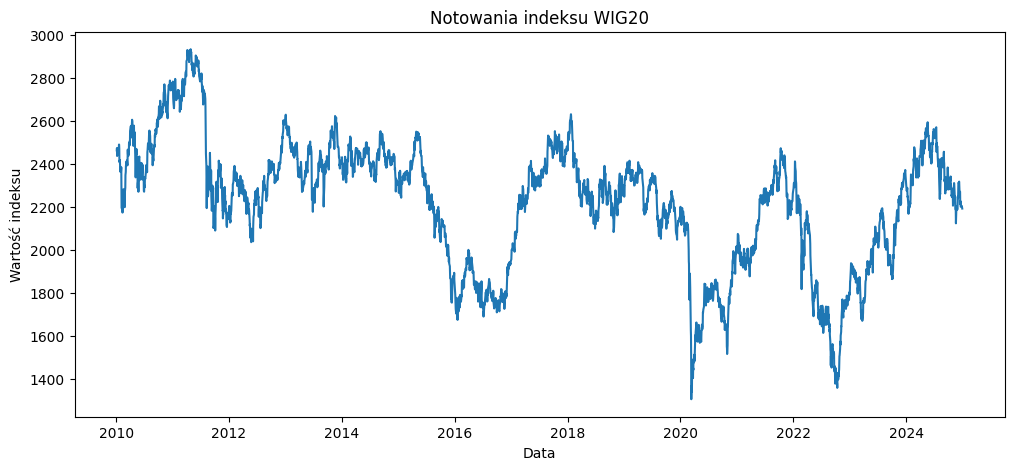

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(wig20["Data"], wig20["WIG20"])
plt.title("Notowania indeksu WIG20")
plt.xlabel("Data")
plt.ylabel("Wartość indeksu")
plt.savefig(f"{sciezka}/wig20_notowaniaindeksu.png", dpi=300, bbox_inches="tight")
plt.show()

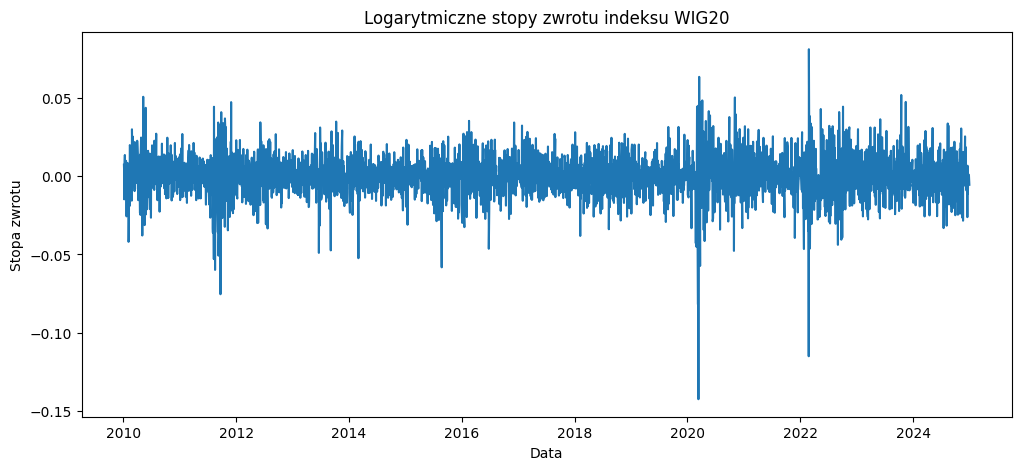

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(wig20["Data"], wig20["stopa_zwrotu"])
plt.title("Logarytmiczne stopy zwrotu indeksu WIG20")
plt.xlabel("Data")
plt.ylabel("Stopa zwrotu")
plt.savefig(f"{sciezka}/wig20stopazwrotu1.png", dpi=300, bbox_inches="tight")
plt.show()

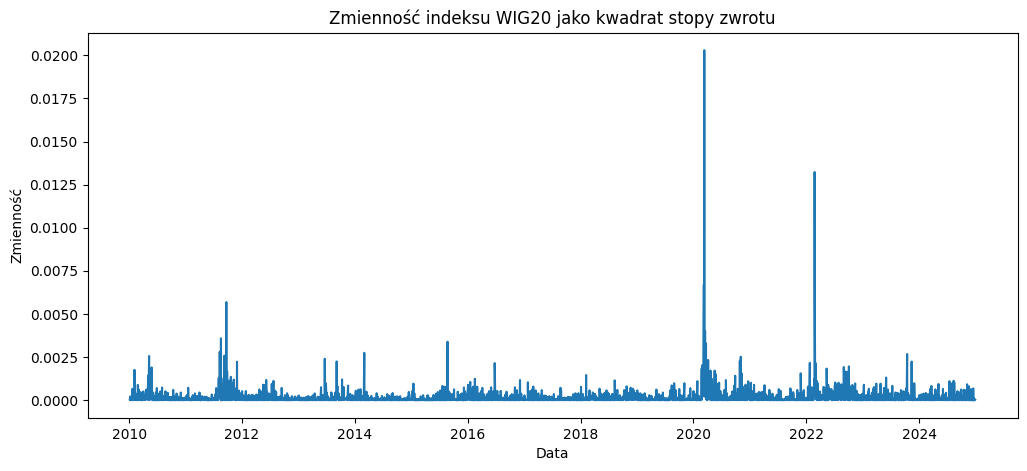

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(wig20["Data"], wig20["zmiennosc"])
plt.title("Zmienność indeksu WIG20 jako kwadrat stopy zwrotu")
plt.xlabel("Data")
plt.ylabel("Zmienność")
plt.savefig(f"{sciezka}/wig20_stopazwrotu.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
wig20.to_csv("wig20_zmiennosc.csv", index=False)

wig20.head()

,Data,WIG20,stopa_zwrotu,zmiennosc
1,2010-01-05,2462.30,0.007223,0.000052
2,2010-01-06,2472.83,0.004267,0.000018
3,2010-01-07,2436.40,-0.014842,0.000220
4,2010-01-08,2440.42,0.001649,0.000003
5,2010-01-11,2473.50,0.013464,0.000181


In [ ]:
#połączenie
inflacja = pd.read_csv("inflacja.csv", sep=";")
inflacja.head()

,Rok,Miesiąc,Wartość,Inflacja
0,2024,1,"103,7","3,7"
1,2024,2,"102,8","2,8"
2,2024,3,"102,0",2
3,2024,4,"102,4","2,4"
4,2024,5,"102,5","2,5"


In [ ]:
vix = pd.read_csv("vix.csv", sep=";")
vix.head()

,Data,VIX
0,31.12.2024,"17,35"
1,30.12.2024,"17,40"
2,27.12.2024,"15,95"
3,26.12.2024,"14,73"
4,24.12.2024,"14,27"


In [ ]:
vix["Data"] = pd.to_datetime(vix["Data"], dayfirst=True)

In [ ]:
vix["Data"] = pd.to_datetime(vix["Data"], dayfirst=True)

In [ ]:
dane = pd.merge(wig20, vix, on="Data", how="left")

In [ ]:
dane.head()

,Data,WIG20,stopa_zwrotu,zmiennosc,VIX
0,2010-01-05,2462.30,0.007223,0.000052,"19,35"
1,2010-01-06,2472.83,0.004267,0.000018,"19,16"
2,2010-01-07,2436.40,-0.014842,0.000220,"19,06"
3,2010-01-08,2440.42,0.001649,0.000003,"18,13"
4,2010-01-11,2473.50,0.013464,0.000181,"17,55"


In [ ]:
inflacja["Data"] = pd.to_datetime(
    inflacja["Rok"].astype(str)
    + "-"
    + inflacja["Miesiąc"].astype(str)
    + "-01"
)

In [ ]:
inflacja = inflacja[["Data", "Inflacja"]]

In [ ]:
#dane = pd.merge(dane, inflacja, on="Data", how="left")

In [ ]:
# upewniamy się, że data w inflacji jest datą
inflacja["Data"] = pd.to_datetime(inflacja["Data"])

# tworzymy rok i miesiąc z daty inflacji
inflacja["Rok"] = inflacja["Data"].dt.year
inflacja["Miesiąc"] = inflacja["Data"].dt.month

# zostawiamy potrzebne kolumny
inflacja_do_merge = inflacja[["Rok", "Miesiąc", "Inflacja"]].copy()

In [ ]:
dane["Data"] = pd.to_datetime(dane["Data"])

dane["Rok"] = dane["Data"].dt.year
dane["Miesiąc"] = dane["Data"].dt.month

dane = pd.merge(dane, inflacja_do_merge, on=["Rok", "Miesiąc"], how="left")

dane.head(20)

,Data,WIG20,stopa_zwrotu,zmiennosc,VIX,Rok,Miesiąc,Inflacja
0,2010-01-05,2462.30,0.007223,5.216513e-05,"19,35",2010,1,"3,5"
1,2010-01-06,2472.83,0.004267,1.821046e-05,"19,16",2010,1,"3,5"
2,2010-01-07,2436.40,-0.014842,2.202762e-04,"19,06",2010,1,"3,5"
3,2010-01-08,2440.42,0.001649,2.717934e-06,"18,13",2010,1,"3,5"
4,2010-01-11,2473.50,0.013464,1.812792e-04,"17,55",2010,1,"3,5"
5,2010-01-12,2448.71,-0.010073,1.014612e-04,"18,25",2010,1,"3,5"
6,2010-01-13,2458.05,0.003807,1.449323e-05,"17,85",2010,1,"3,5"
7,2010-01-14,2451.98,-0.002472,6.113213e-06,"17,63",2010,1,"3,5"
8,2010-01-15,2442.38,-0.003923,1.538905e-05,"17,91",2010,1,"3,5"
9,2010-01-18,2465.30,0.009341,8.724550e-05,NaN,2010,1,"3,5"


In [ ]:
dane.head(20)

,Data,WIG20,stopa_zwrotu,zmiennosc,VIX,Rok,Miesiąc,Inflacja
0,2010-01-05,2462.30,0.007223,5.216513e-05,"19,35",2010,1,"3,5"
1,2010-01-06,2472.83,0.004267,1.821046e-05,"19,16",2010,1,"3,5"
2,2010-01-07,2436.40,-0.014842,2.202762e-04,"19,06",2010,1,"3,5"
3,2010-01-08,2440.42,0.001649,2.717934e-06,"18,13",2010,1,"3,5"
4,2010-01-11,2473.50,0.013464,1.812792e-04,"17,55",2010,1,"3,5"
5,2010-01-12,2448.71,-0.010073,1.014612e-04,"18,25",2010,1,"3,5"
6,2010-01-13,2458.05,0.003807,1.449323e-05,"17,85",2010,1,"3,5"
7,2010-01-14,2451.98,-0.002472,6.113213e-06,"17,63",2010,1,"3,5"
8,2010-01-15,2442.38,-0.003923,1.538905e-05,"17,91",2010,1,"3,5"
9,2010-01-18,2465.30,0.009341,8.724550e-05,NaN,2010,1,"3,5"


In [ ]:
dane = dane.rename(columns={"Inflacja_y": "Inflacja"})

In [ ]:
#dane = dane.drop(columns=["Inflacja_x"])

In [ ]:
#dane = dane.drop(columns=["Rok", "Miesiąc"])

In [ ]:
#dane.to_csv("finalny_dataset.csv", index=False)

In [ ]:
#EDA

In [ ]:
import pandas as pd

dane = pd.read_csv("finalny_dataset.csv")

In [ ]:
dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3748 entries, 0 to 3747
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Data          3748 non-null   object 
 1   WIG20         3748 non-null   float64
 2   stopa_zwrotu  3748 non-null   float64
 3   zmiennosc     3748 non-null   float64
 4   VIX           3671 non-null   object 
 5   Inflacja      3748 non-null   object 
dtypes: float64(3), object(3)
memory usage: 175.8+ KB


In [ ]:
dane.describe()

,WIG20,stopa_zwrotu,zmiennosc
count,3748.000000,3748.000000,3748.000000
mean,2217.515891,-0.000029,0.000172
std,291.322505,0.013129,0.000530
min,1305.730000,-0.142456,0.000000
25%,2036.182500,-0.007062,0.000010
50%,2276.615000,0.000073,0.000050
75%,2405.832500,0.007121,0.000169
max,2932.620000,0.080995,0.020294


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
dane["Data"] = pd.to_datetime(dane["Data"])

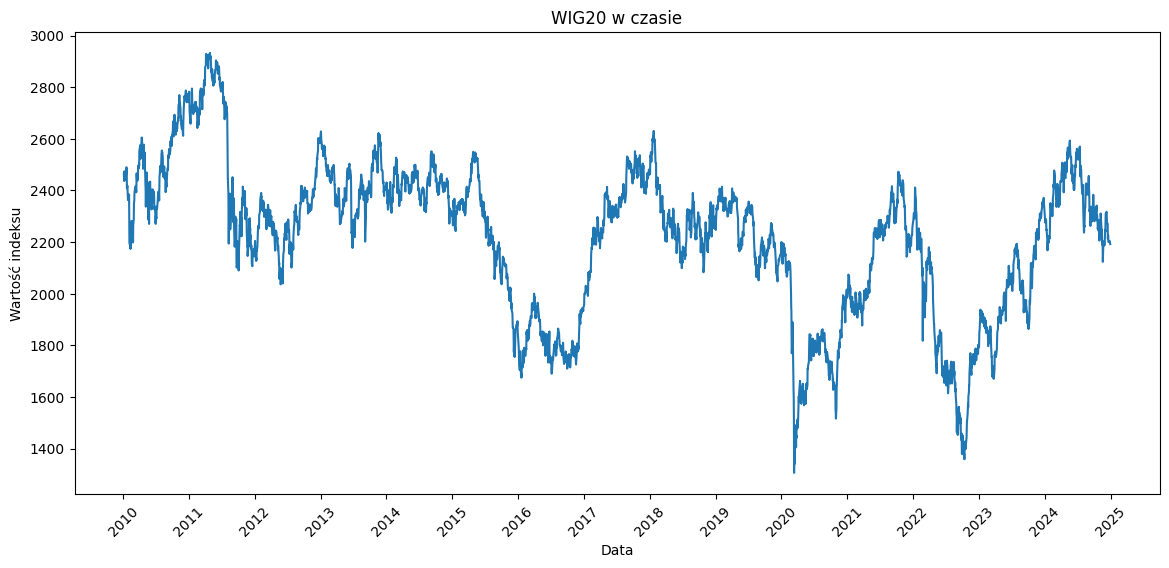

In [ ]:
#wykre wig20
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

plt.plot(dane["Data"], dane["WIG20"])

plt.title("WIG20 w czasie")
plt.xlabel("Data")
plt.ylabel("Wartość indeksu")

# pokazuj lata
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

# format roku
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.savefig(f"{sciezka}/WIG20wczasie.png", dpi=300, bbox_inches="tight")
plt.show()

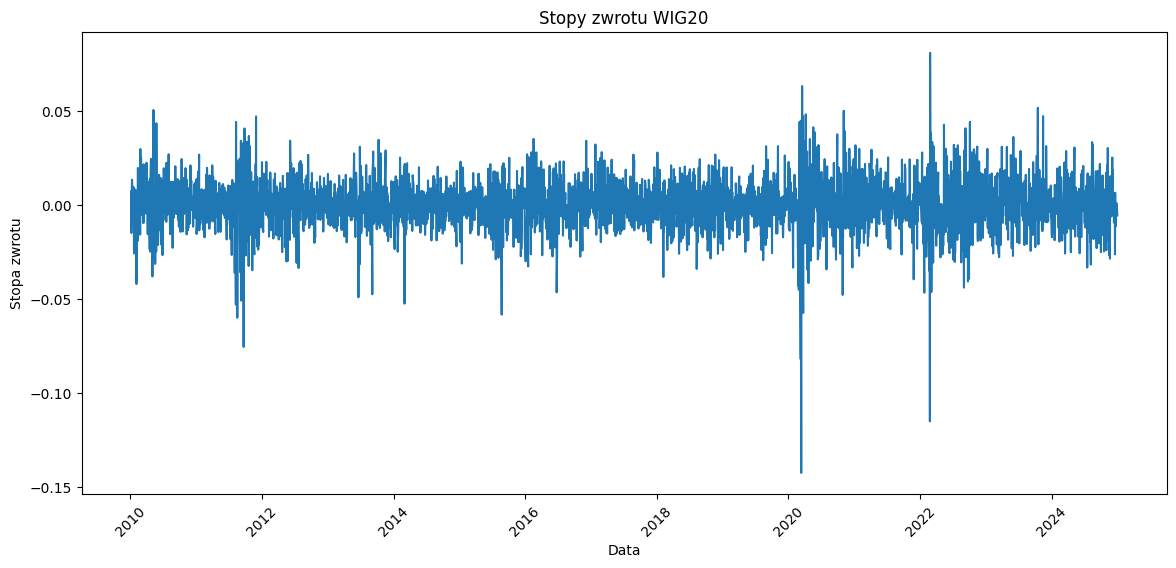

In [ ]:
#wykres stóp zwrotu
plt.figure(figsize=(14,6))

plt.plot(dane["Data"], dane["stopa_zwrotu"])

plt.title("Stopy zwrotu WIG20")
plt.xlabel("Data")
plt.ylabel("Stopa zwrotu")

plt.xticks(rotation=45)
plt.savefig(f"{sciezka}/Stopy_zwrotuWIG20.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
dane = dane.rename(columns={"zmiennosc": "Zmienność"})

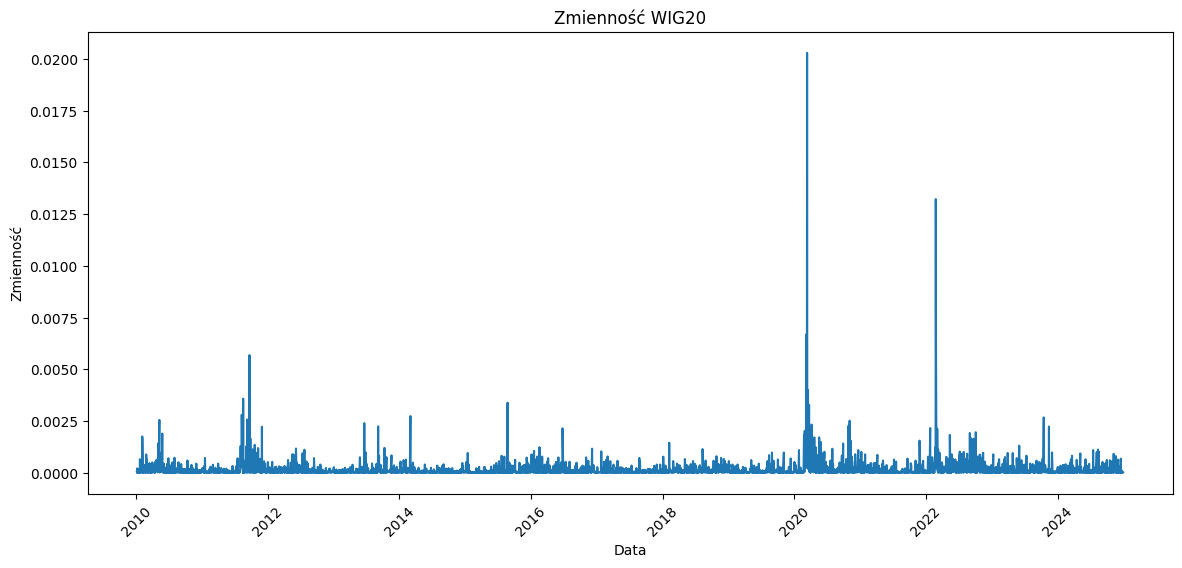

In [ ]:
#wykres zmienności
plt.figure(figsize=(14,6))

plt.plot(dane["Data"], dane["Zmienność"])

plt.title("Zmienność WIG20")
plt.xlabel("Data")
plt.ylabel("Zmienność")

plt.xticks(rotation=45)
plt.savefig(f"{sciezka}/ZmiennośćWIG20.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
dane["VIX"] = dane["VIX"].astype(str).str.replace(",", ".").astype(float)
dane["Inflacja"] = dane["Inflacja"].astype(str).str.replace(",", ".").astype(float)

In [ ]:
dane[["Zmienność", "VIX", "Inflacja"]].corr()

,Zmienność,VIX,Inflacja
Zmienność,1.000000,0.341847,0.088237
VIX,0.341847,1.000000,0.302414
Inflacja,0.088237,0.302414,1.000000


In [ ]:
#dane[["Zmienność", "VIX", "Inflacja"]].corr()

In [ ]:
#analiza statystyczna + heatmapa

In [ ]:
#opisy statystyczne
dane[["WIG20", "stopa_zwrotu", "Zmienność", "VIX", "Inflacja"]].describe()

,WIG20,stopa_zwrotu,Zmienność,VIX,Inflacja
count,3748.000000,3748.000000,3748.000000,3671.000000,3748.000000
mean,2217.515891,-0.000029,0.000172,18.397810,3.602321
std,291.322505,0.013129,0.000530,6.979355,4.339537
min,1305.730000,-0.142456,0.000000,9.140000,-1.600000
25%,2036.182500,-0.007062,0.000010,13.600000,1.100000
50%,2276.615000,0.000073,0.000050,16.610000,2.600000
75%,2405.832500,0.007121,0.000169,21.230000,4.300000
max,2932.620000,0.080995,0.020294,82.690000,18.400000


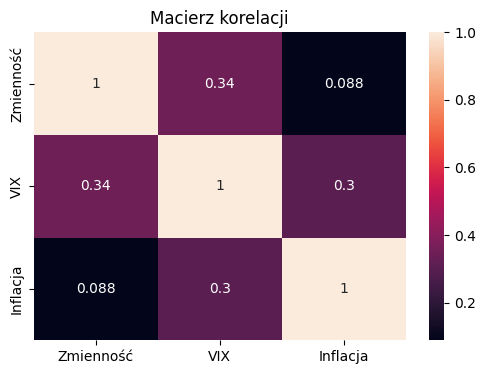

In [ ]:
#heatmapa korelacji
import seaborn as sns
import matplotlib.pyplot as plt

corr = dane[["Zmienność", "VIX", "Inflacja"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)

plt.title("Macierz korelacji")
plt.savefig(f"{sciezka}/MacierzKorelacji.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#model GARCH

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 20.1 MB/s eta 0:00:00


In [ ]:
from arch import arch_model

In [ ]:
model = arch_model(
    dane["stopa_zwrotu"].dropna()*100,
    vol="Garch",
    p=1,
    q=1
)

wynik = model.fit()

print(wynik.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3576288622961.852
Iteration:      2,   Func. Count:     15,   Neg. LLF: 16415149732.10971
Iteration:      3,   Func. Count:     23,   Neg. LLF: 8412.242771205754
Iteration:      4,   Func. Count:     30,   Neg. LLF: 6035.4558958129965
Iteration:      5,   Func. Count:     36,   Neg. LLF: 6472.879455819145
Iteration:      6,   Func. Count:     42,   Neg. LLF: 6018.209212820772
Iteration:      7,   Func. Count:     48,   Neg. LLF: 6016.55491795759
Iteration:      8,   Func. Count:     53,   Neg. LLF: 6016.534370103444
Iteration:      9,   Func. Count:     58,   Neg. LLF: 6016.534334087138
Iteration:     10,   Func. Count:     63,   Neg. LLF: 6016.534332363857
Iteration:     11,   Func. Count:     67,   Neg. LLF: 6016.534332365411
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6016.534332363857
            Iterations: 11
            Function evaluations: 67
            Gradient evaluations: 11

In [ ]:
#wykres zmienności z modelu GARCH
garch_volatility = wynik.conditional_volatility #wyciągamy zmienność z modelu

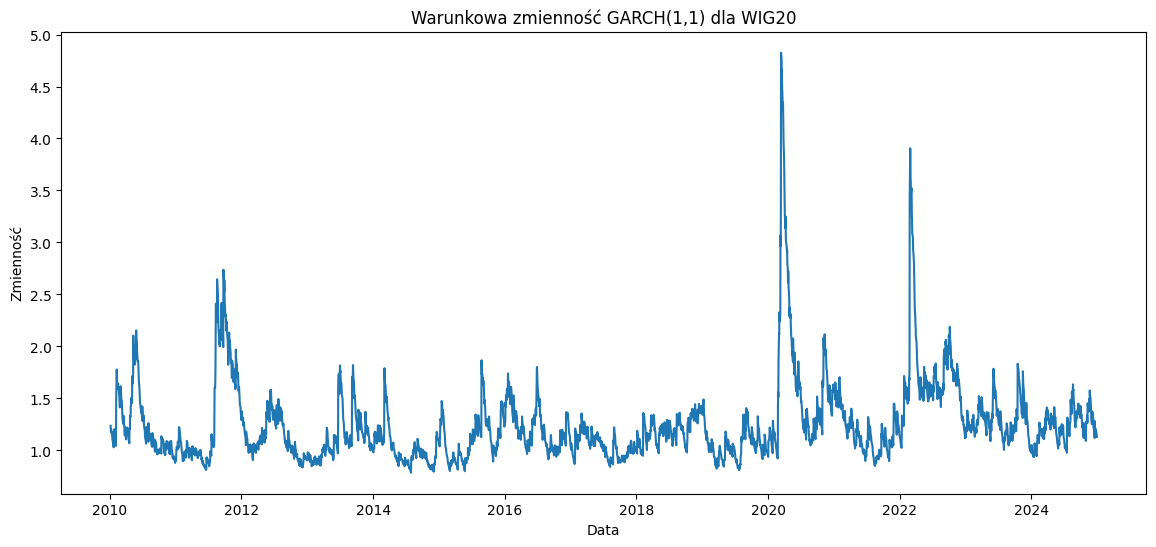

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(dane["Data"].iloc[-len(garch_volatility):],
         garch_volatility)

plt.title("Warunkowa zmienność GARCH(1,1) dla WIG20")
plt.xlabel("Data")
plt.ylabel("Zmienność")
plt.savefig("GARCH_zmienność.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#części „AI / machine learning

In [ ]:
#przygotowanie danych
from sklearn.model_selection import train_test_split

X = dane[["VIX", "Inflacja"]]
y = dane["Zmienność"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#model Random Forest
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#prognoza
y_pred = model_rf.predict(X_test)

In [ ]:
#ocena modelu
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 5.069381268810502e-07
R2: -4.948747895033255


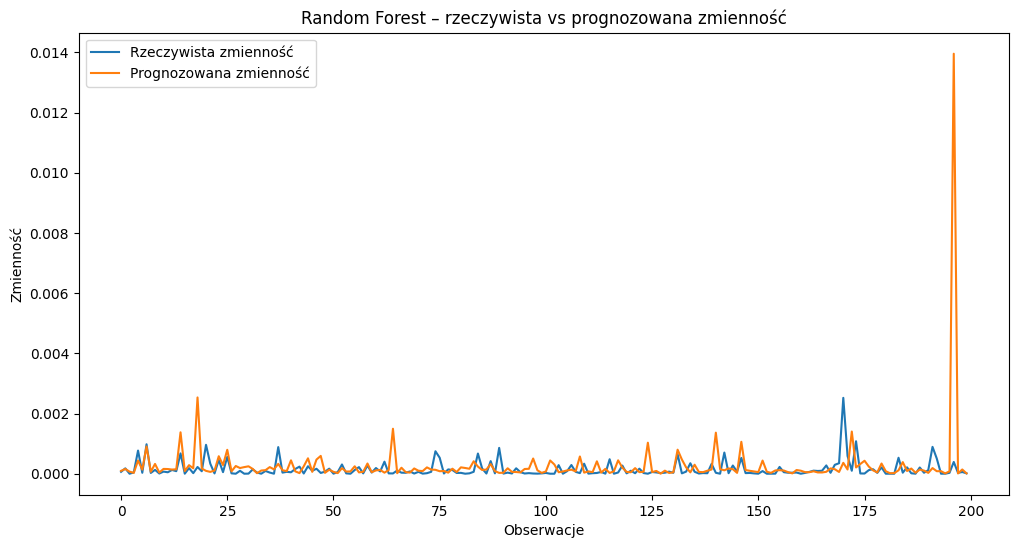

In [ ]:
#wykres rzeczywiste vs przewidywane
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Rzeczywista zmienność")
plt.plot(y_pred[:200], label="Prognozowana zmienność")

plt.title("Random Forest – rzeczywista vs prognozowana zmienność")
plt.xlabel("Obserwacje")
plt.ylabel("Zmienność")

plt.legend()
plt.savefig(f"{sciezka}/RF_prognoza.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#prognoza
y_pred_xgb = model_xgb.predict(X_test)

In [ ]:
#ocena modelu
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MSE XGBoost:", mse_xgb)
print("R2 XGBoost:", r2_xgb)

MSE XGBoost: 1.0768992543062751e-07
R2 XGBoost: -0.2637049439606485


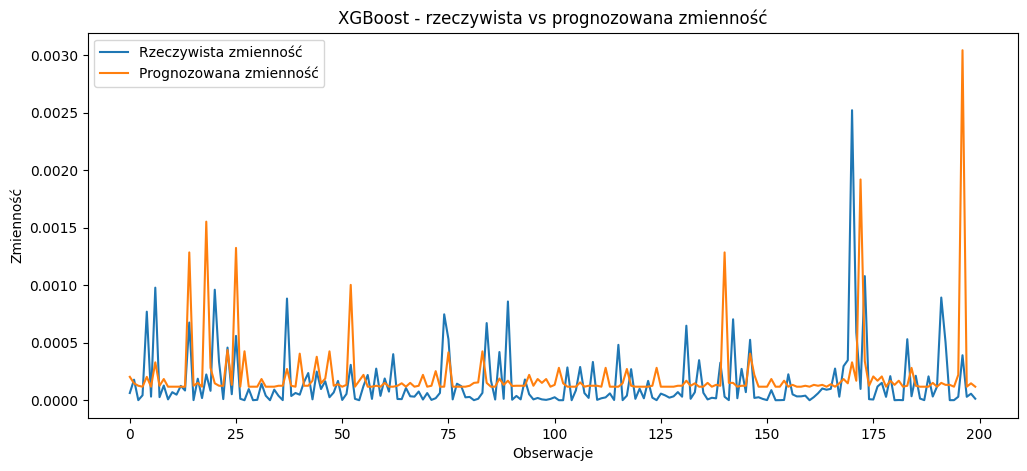

In [ ]:
#wykres
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Rzeczywista zmienność")
plt.plot(y_pred_xgb[:200], label="Prognozowana zmienność")

plt.title("XGBoost - rzeczywista vs prognozowana zmienność")
plt.xlabel("Obserwacje")
plt.ylabel("Zmienność")

plt.legend()
plt.savefig(f"{sciezka}/XGBoost_prognoza.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#abela porównawcza modeli

In [ ]:
import pandas as pd

wyniki = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MSE": [mse, mse_xgb],
    "R2": [r2, r2_xgb]
})

print(wyniki)

           Model           MSE        R2
0  Random Forest  5.069381e-07 -4.948748
1        XGBoost  1.076899e-07 -0.263705


In [ ]:
wyniki.to_csv("wyniki_modeli.csv", index=False)

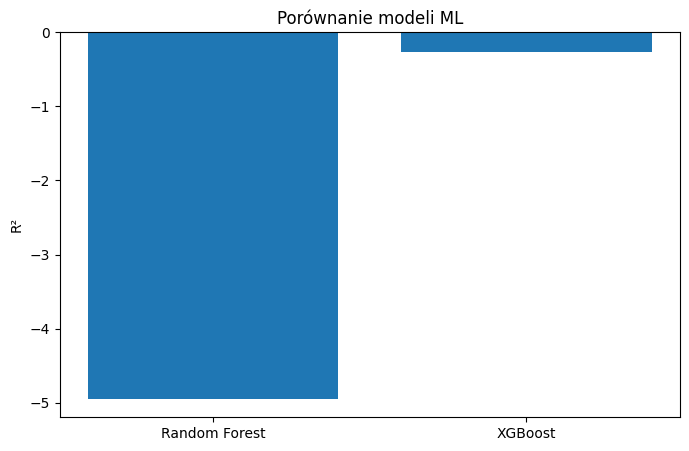

In [ ]:
#wykres porównawczy modeli
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(wyniki["Model"], wyniki["R2"])

plt.title("Porównanie modeli ML")
plt.ylabel("R²")
plt.savefig(f"{sciezka}/Porównanie_modeli.png", dpi=300, bbox_inches="tight")

plt.show()

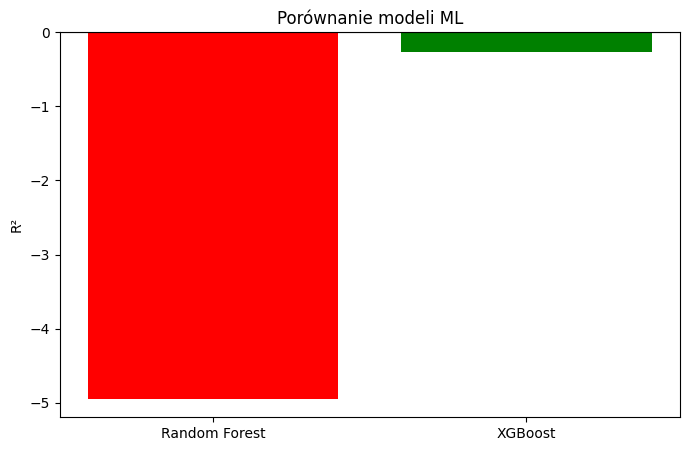

In [ ]:
plt.figure(figsize=(8,5))

kolory = ["red", "green"]

plt.bar(wyniki["Model"], wyniki["R2"], color=kolory)

plt.axhline(0, color='black')

plt.title("Porównanie modeli ML")
plt.ylabel("R²")
plt.savefig(f"{sciezka}/Porównanie_modeli_kolor.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#feature importance

In [ ]:
#RF: które zmienne były najważniejsze dla AI
waznosc_rf = pd.DataFrame({
    "Zmienna": X.columns,
    "Ważność": model_rf.feature_importances_
})

print(waznosc_rf)

    Zmienna  Ważność
0       VIX  0.84306
1  Inflacja  0.15694


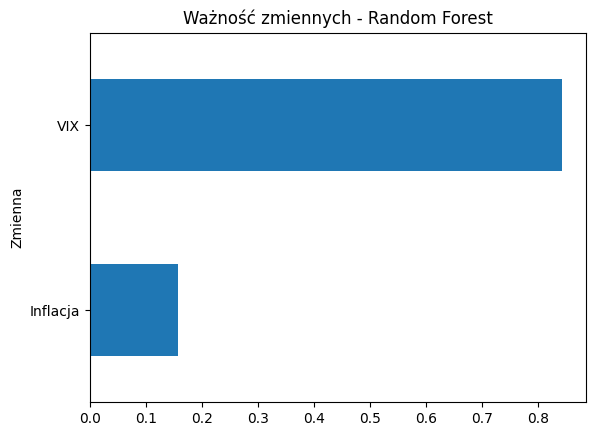

In [ ]:
waznosc_rf.sort_values("Ważność").plot(
    x="Zmienna",
    y="Ważność",
    kind="barh",
    legend=False
)

plt.title("Ważność zmiennych - Random Forest")
plt.savefig(f"{sciezka}/featureimportance_rf.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#XGBoost: które zmienne były najważniejsze dla AI
import pandas as pd

waznosc = pd.DataFrame({
    "Zmienna": X.columns,
    "Ważność": model_xgb.feature_importances_
})

print(waznosc)

    Zmienna   Ważność
0       VIX  0.618871
1  Inflacja  0.381129


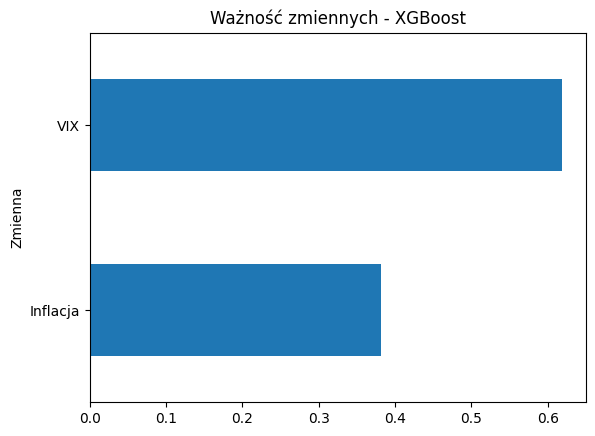

In [ ]:
waznosc.sort_values("Ważność").plot(
    x="Zmienna",
    y="Ważność",
    kind="barh",
    legend=False
)

plt.title("Ważność zmiennych - XGBoost")
plt.savefig(f"{sciezka}/featureimportance_xgb.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#druga część

In [ ]:
dane["Data"] = pd.to_datetime(dane["Data"])

dane["VIX"] = dane["VIX"].astype(str).str.replace(",", ".").astype(float)
dane["Inflacja"] = dane["Inflacja"].astype(str).str.replace(",", ".").astype(float)


dane.head()

,Data,WIG20,stopa_zwrotu,Zmienność,VIX,Inflacja
0,2010-01-05,2462.30,0.007223,0.000052,19.35,3.5
1,2010-01-06,2472.83,0.004267,0.000018,19.16,3.5
2,2010-01-07,2436.40,-0.014842,0.000220,19.06,3.5
3,2010-01-08,2440.42,0.001649,0.000003,18.13,3.5
4,2010-01-11,2473.50,0.013464,0.000181,17.55,3.5


In [ ]:
dane_mag = dane.copy()

dane_mag = dane_mag.sort_values("Data")

dane_mag.head()

,Data,WIG20,stopa_zwrotu,Zmienność,VIX,Inflacja
0,2010-01-05,2462.30,0.007223,0.000052,19.35,3.5
1,2010-01-06,2472.83,0.004267,0.000018,19.16,3.5
2,2010-01-07,2436.40,-0.014842,0.000220,19.06,3.5
3,2010-01-08,2440.42,0.001649,0.000003,18.13,3.5
4,2010-01-11,2473.50,0.013464,0.000181,17.55,3.5


In [ ]:
#Dodajemy nowe zmienne: lagi i rolling volatility

# opóźnienia zmienności
dane_mag["zmiennosc_lag1"] = dane_mag["Zmienność"].shift(1)
dane_mag["zmiennosc_lag2"] = dane_mag["Zmienność"].shift(2)
dane_mag["zmiennosc_lag5"] = dane_mag["Zmienność"].shift(5)

# opóźnienia stóp zwrotu
dane_mag["stopa_lag1"] = dane_mag["stopa_zwrotu"].shift(1)
dane_mag["stopa_lag2"] = dane_mag["stopa_zwrotu"].shift(2)
dane_mag["stopa_lag5"] = dane_mag["stopa_zwrotu"].shift(5)

# krocząca zmienność
dane_mag["rolling_vol_5"] = dane_mag["stopa_zwrotu"].rolling(5).std()
dane_mag["rolling_vol_10"] = dane_mag["stopa_zwrotu"].rolling(10).std()
dane_mag["rolling_vol_20"] = dane_mag["stopa_zwrotu"].rolling(20).std()

dane_mag.head(25)

,Data,WIG20,stopa_zwrotu,Zmienność,VIX,Inflacja,zmiennosc_lag1,zmiennosc_lag2,zmiennosc_lag5,stopa_lag1,stopa_lag2,stopa_lag5,rolling_vol_5,rolling_vol_10,rolling_vol_20
0,2010-01-05,2462.30,0.007223,5.216513e-05,19.35,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-06,2472.83,0.004267,1.821046e-05,19.16,3.5,5.216513e-05,NaN,NaN,0.007223,NaN,NaN,NaN,NaN,NaN
2,2010-01-07,2436.40,-0.014842,2.202762e-04,19.06,3.5,1.821046e-05,5.216513e-05,NaN,0.004267,0.007223,NaN,NaN,NaN,NaN
3,2010-01-08,2440.42,0.001649,2.717934e-06,18.13,3.5,2.202762e-04,1.821046e-05,NaN,-0.014842,0.004267,NaN,NaN,NaN,NaN
4,2010-01-11,2473.50,0.013464,1.812792e-04,17.55,3.5,2.717934e-06,2.202762e-04,NaN,0.001649,-0.014842,NaN,0.010571,NaN,NaN
5,2010-01-12,2448.71,-0.010073,1.014612e-04,18.25,3.5,1.812792e-04,2.717934e-06,5.216513e-05,0.013464,0.001649,0.007223,0.011378,NaN,NaN
6,2010-01-13,2458.05,0.003807,1.449323e-05,17.85,3.5,1.014612e-04,1.812792e-04,1.821046e-05,-0.010073,0.013464,0.004267,0.011325,NaN,NaN
7,2010-01-14,2451.98,-0.002472,6.113213e-06,17.63,3.5,1.449323e-05,1.014612e-04,2.202762e-04,0.003807,-0.010073,-0.014842,0.008630,NaN,NaN
8,2010-01-15,2442.38,-0.003923,1.538905e-05,17.91,3.5,6.113213e-06,1.449323e-05,2.717934e-06,-0.002472,0.003807,0.001649,0.008925,NaN,NaN
9,2010-01-18,2465.30,0.009341,8.724550e-05,NaN,3.5,1.538905e-05,6.113213e-06,1.812792e-04,-0.003923,-0.002472,0.013464,0.007458,0.008770,NaN


In [ ]:
dane_mag = dane_mag.dropna()

dane_mag.isna().sum()

,0
Data,0
WIG20,0
stopa_zwrotu,0
Zmienność,0
VIX,0
Inflacja,0
zmiennosc_lag1,0
zmiennosc_lag2,0
zmiennosc_lag5,0
stopa_lag1,0


In [ ]:
#poprawny podział czasowy
train = dane_mag[dane_mag["Data"] < "2021-01-01"]
test = dane_mag[dane_mag["Data"] >= "2021-01-01"]

print("Train:", train["Data"].min(), train["Data"].max())
print("Test:", test["Data"].min(), test["Data"].max())

Train: 2010-02-01 00:00:00 2020-12-30 00:00:00
Test: 2021-01-04 00:00:00 2024-12-30 00:00:00


In [ ]:
#wybieramy zmienne do modeli ML

cechy = [
    "VIX",
    "Inflacja",
    "zmiennosc_lag1",
    "zmiennosc_lag2",
    "zmiennosc_lag5",
    "stopa_lag1",
    "stopa_lag2",
    "stopa_lag5",
    "rolling_vol_5",
    "rolling_vol_10",
    "rolling_vol_20"
]

X_train = train[cechy]
y_train = train["Zmienność"]

X_test = test[cechy]
y_test = test["Zmienność"]

In [ ]:
#Tworzymy funkcję do oceny modeli

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def ocena_modelu(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2

In [ ]:
#Ulepszony Random Forest

from sklearn.ensemble import RandomForestRegressor

model_rf_mag = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

model_rf_mag.fit(X_train, y_train)

y_pred_rf_mag = model_rf_mag.predict(X_test)

mse_rf, rmse_rf, mae_rf, r2_rf = ocena_modelu(y_test, y_pred_rf_mag)

print("Random Forest")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
MSE: 1.546821386029294e-07
RMSE: 0.00039329650214937
MAE: 0.00018663172210891176
R2: 0.4853667985404143


In [ ]:
#Ulepszony XGBoost

from xgboost import XGBRegressor

model_xgb_mag = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb_mag.fit(X_train, y_train)

y_pred_xgb_mag = model_xgb_mag.predict(X_test)

mse_xgb, rmse_xgb, mae_xgb, r2_xgb = ocena_modelu(y_test, y_pred_xgb_mag)

print("XGBoost")
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost
MSE: 1.4001200208351825e-07
RMSE: 0.00037418177679240103
MAE: 0.00018363896743906564
R2: 0.5341748858284625


In [ ]:
#Tabela porównawcza modeli ML

wyniki_ml_mag = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MSE": [mse_rf, mse_xgb],
    "RMSE": [rmse_rf, rmse_xgb],
    "MAE": [mae_rf, mae_xgb],
    "R2": [r2_rf, r2_xgb]
})

wyniki_ml_mag

,Model,MSE,RMSE,MAE,R2
0,Random Forest,1.546821e-07,0.000393,0.000187,0.485367
1,XGBoost,1.400120e-07,0.000374,0.000184,0.534175


In [ ]:
wyniki_ml_mag.to_csv(f"{sciezka}/wyniki_ml_magisterskie.csv", index=False)

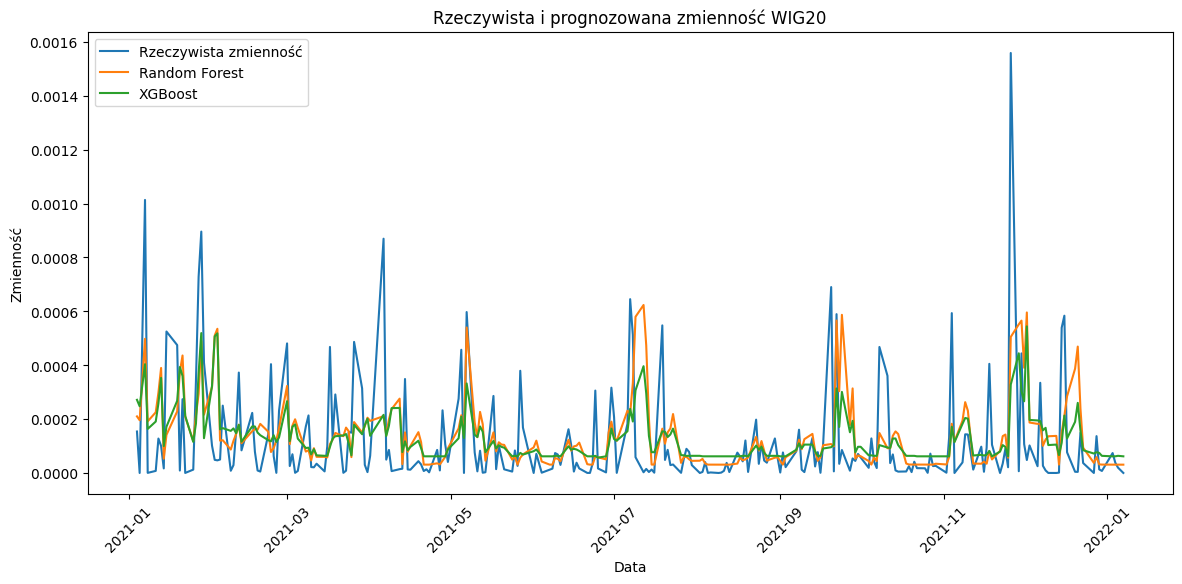

In [ ]:
#Wykres: rzeczywista vs prognozowana zmienność

plt.figure(figsize=(14,6))

plt.plot(test["Data"].iloc[:250], y_test.iloc[:250], label="Rzeczywista zmienność")
plt.plot(test["Data"].iloc[:250], y_pred_rf_mag[:250], label="Random Forest")
plt.plot(test["Data"].iloc[:250], y_pred_xgb_mag[:250], label="XGBoost")

plt.title("Rzeczywista i prognozowana zmienność WIG20")
plt.xlabel("Data")
plt.ylabel("Zmienność")
plt.legend()
plt.xticks(rotation=45)

plt.savefig(f"{sciezka}/prognozy_ml_magisterskie.png", dpi=300, bbox_inches="tight")

plt.show()

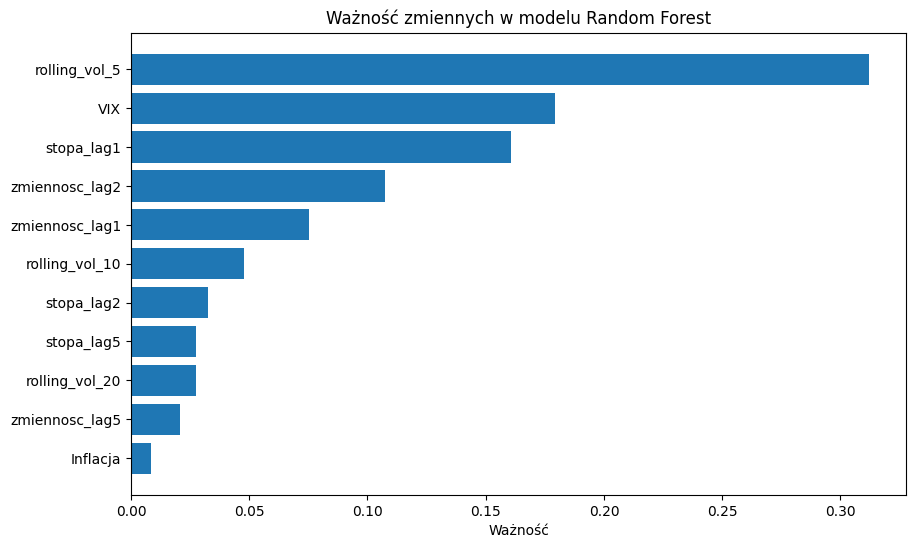

In [ ]:
#Feature importance dla Random Forest

waznosc_rf_mag = pd.DataFrame({
    "Zmienna": cechy,
    "Ważność": model_rf_mag.feature_importances_
}).sort_values("Ważność", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(waznosc_rf_mag["Zmienna"], waznosc_rf_mag["Ważność"])

plt.title("Ważność zmiennych w modelu Random Forest")
plt.xlabel("Ważność")

plt.savefig(f"{sciezka}/feature_importance_rf_magisterskie.png", dpi=300, bbox_inches="tight")

plt.show()

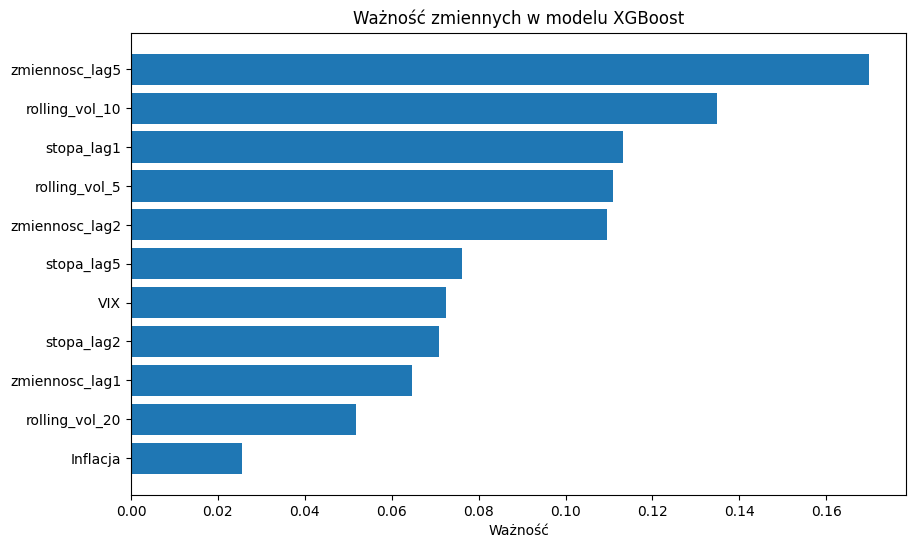

In [ ]:
#Feature importance dla XGBoost

waznosc_xgb_mag = pd.DataFrame({
    "Zmienna": cechy,
    "Ważność": model_xgb_mag.feature_importances_
}).sort_values("Ważność", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(waznosc_xgb_mag["Zmienna"], waznosc_xgb_mag["Ważność"])

plt.title("Ważność zmiennych w modelu XGBoost")
plt.xlabel("Ważność")

plt.savefig(f"{sciezka}/feature_importance_xgb_magisterskie.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#EGARCH i GJR-GARCH

In [ ]:
from arch import arch_model

In [ ]:
returns = dane_mag["stopa_zwrotu"].dropna() * 100

In [ ]:
#klasyczny GARCH (1,1)   JESZCZE RAZ DLA PORÓWNANIA

garch = arch_model(
    returns,
    vol="GARCH",
    p=1,
    q=1,
    mean="Constant",
    dist="normal"
)

wynik_garch = garch.fit(disp="off")

print(wynik_garch.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:           stopa_zwrotu   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5883.46
Distribution:                  Normal   AIC:                           11774.9
Method:            Maximum Likelihood   BIC:                           11799.7
                                        No. Observations:                 3653
Date:                Sun, May 10 2026   Df Residuals:                     3652
Time:                        13:13:05   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0122  1.817e-02      0.670      0.503 

In [ ]:
#EGARCH(1,1)

egarch = arch_model(
    returns,
    vol="EGARCH",
    p=1,
    q=1,
    mean="Constant",
    dist="normal"
)

wynik_egarch = egarch.fit(disp="off")

print(wynik_egarch.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:           stopa_zwrotu   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -5884.07
Distribution:                  Normal   AIC:                           11776.1
Method:            Maximum Likelihood   BIC:                           11801.0
                                        No. Observations:                 3653
Date:                Sun, May 10 2026   Df Residuals:                     3652
Time:                        13:13:31   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0143  1.799e-02      0.792      0.428 

In [ ]:
#GJR-GARCH(1,1)

gjr_garch = arch_model(
    returns,
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    mean="Constant",
    dist="normal"
)

wynik_gjr = gjr_garch.fit(disp="off")

print(wynik_gjr.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:           stopa_zwrotu   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -5843.23
Distribution:                  Normal   AIC:                           11696.5
Method:            Maximum Likelihood   BIC:                           11727.5
                                        No. Observations:                 3653
Date:                Sun, May 10 2026   Df Residuals:                     3652
Time:                        13:13:54   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu            -0.0145  1.853e-02     -0.785      0.433 

In [ ]:
#tabela porównawcza modeli GARCH

wyniki_garch = pd.DataFrame({
    "Model": ["GARCH(1,1)", "EGARCH(1,1)", "GJR-GARCH(1,1)"],
    "AIC": [wynik_garch.aic, wynik_egarch.aic, wynik_gjr.aic],
    "BIC": [wynik_garch.bic, wynik_egarch.bic, wynik_gjr.bic],
    "Log-Likelihood": [
        wynik_garch.loglikelihood,
        wynik_egarch.loglikelihood,
        wynik_gjr.loglikelihood
    ]
})

wyniki_garch

,Model,AIC,BIC,Log-Likelihood
0,"GARCH(1,1)",11774.926415,11799.739631,-5883.463208
1,"EGARCH(1,1)",11776.143209,11800.956425,-5884.071605
2,"GJR-GARCH(1,1)",11696.453135,11727.469655,-5843.226567


In [ ]:
wyniki_garch.to_csv(f"{sciezka}/wyniki_garch_egarch_gjr.csv", index=False)

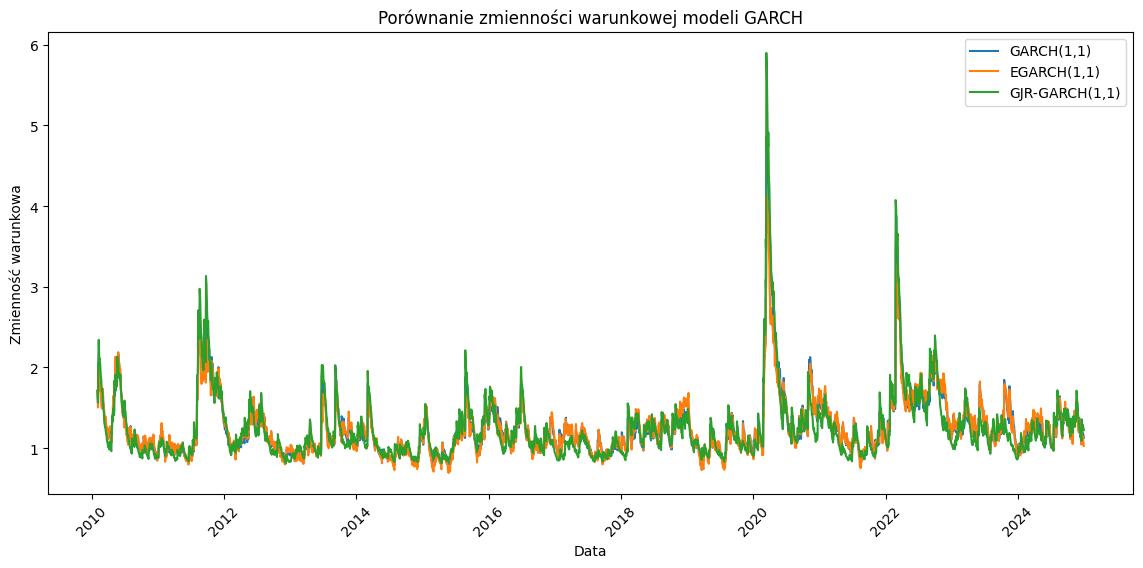

In [ ]:
#wykres porównania zmienności warunkowej

plt.figure(figsize=(14,6))

plt.plot(dane_mag["Data"].iloc[-len(wynik_garch.conditional_volatility):],
         wynik_garch.conditional_volatility,
         label="GARCH(1,1)")

plt.plot(dane_mag["Data"].iloc[-len(wynik_egarch.conditional_volatility):],
         wynik_egarch.conditional_volatility,
         label="EGARCH(1,1)")

plt.plot(dane_mag["Data"].iloc[-len(wynik_gjr.conditional_volatility):],
         wynik_gjr.conditional_volatility,
         label="GJR-GARCH(1,1)")

plt.title("Porównanie zmienności warunkowej modeli GARCH")
plt.xlabel("Data")
plt.ylabel("Zmienność warunkowa")
plt.legend()
plt.xticks(rotation=45)

plt.savefig(f"{sciezka}/porownanie_garch_egarch_gjr.png", dpi=300, bbox_inches="tight")

plt.show()

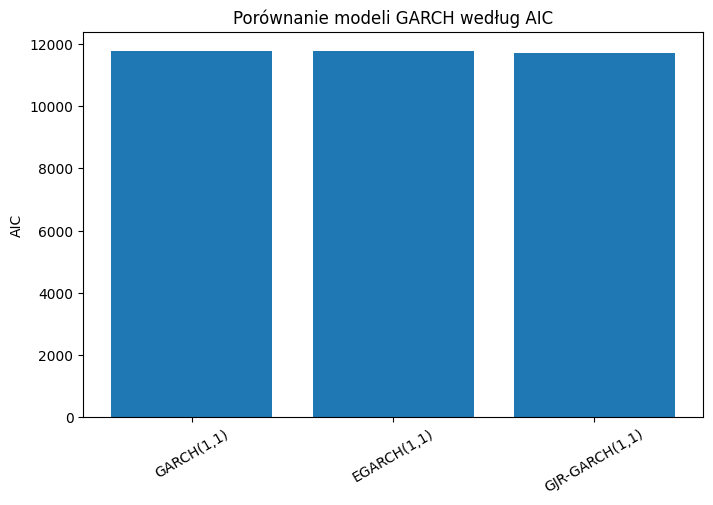

In [ ]:
#wykres AIC/BIC

plt.figure(figsize=(8,5))

plt.bar(wyniki_garch["Model"], wyniki_garch["AIC"])

plt.title("Porównanie modeli GARCH według AIC")
plt.ylabel("AIC")
plt.xticks(rotation=30)

plt.savefig(f"{sciezka}/porownanie_aic_garch.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#Prognozowanie out-of-sample modeli GARCH

# stopy zwrotu ×100
returns = dane_mag["stopa_zwrotu"].dropna() * 100

# podział czasowy
train_returns = returns[dane_mag["Data"] < "2021-01-01"]
test_returns = returns[dane_mag["Data"] >= "2021-01-01"]

print(len(train_returns))
print(len(test_returns))

2660
993


In [ ]:
#prognozy out-of-sample dla GARCH, EGARCH i GJR-GARCH

returns_all = dane_mag.set_index("Data")["stopa_zwrotu"].dropna() * 100
split_date = "2021-01-01"

def prognoza_modelu_garch(vol_type="GARCH", p=1, o=0, q=1):
    model = arch_model(
        returns_all,
        vol=vol_type,
        p=p,
        o=o,
        q=q,
        mean="Constant",
        dist="normal"
    )

    wynik = model.fit(
        last_obs="2020-12-31",
        disp="off"
    )

    forecast = wynik.forecast(
        horizon=1,
        start=split_date,
        reindex=True
    )

    prognoza = np.sqrt(forecast.variance["h.1"]).dropna() / 100

    return wynik, prognoza


wynik_garch_oos, prognoza_garch = prognoza_modelu_garch(
    vol_type="GARCH",
    p=1,
    o=0,
    q=1
)

wynik_egarch_oos, prognoza_egarch = prognoza_modelu_garch(
    vol_type="EGARCH",
    p=1,
    o=0,
    q=1
)

wynik_gjr_oos, prognoza_gjr = prognoza_modelu_garch(
    vol_type="GARCH",
    p=1,
    o=1,
    q=1
)

In [ ]:
#ocena modeli

rzeczywista_garch = abs(returns_all.loc[prognoza_garch.index] / 100)

mse_garch, rmse_garch, mae_garch, r2_garch = ocena_prognoz(
    rzeczywista_garch,
    prognoza_garch
)

mse_egarch, rmse_egarch, mae_egarch, r2_egarch = ocena_prognoz(
    rzeczywista_garch,
    prognoza_egarch
)

mse_gjr, rmse_gjr, mae_gjr, r2_gjr = ocena_prognoz(
    rzeczywista_garch,
    prognoza_gjr
)

print("GARCH:", mse_garch, rmse_garch, mae_garch, r2_garch)
print("EGARCH:", mse_egarch, rmse_egarch, mae_egarch, r2_egarch)
print("GJR-GARCH:", mse_gjr, rmse_gjr, mae_gjr, r2_gjr)

GARCH: 8.051274618455705e-05 0.008972889511442624 0.007137561268150686 0.12792055177006945
EGARCH: 8.088619068652534e-05 0.0089936750378544 0.007135961336855583 0.12387556149642409
GJR-GARCH: 7.920678161462625e-05 0.008899819189996291 0.006984290641883187 0.14206619845987933


In [ ]:
#finalna tabela

porownanie_final = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "GARCH",
        "EGARCH",
        "GJR-GARCH"
    ],
    "MSE": [
        mse_rf,
        mse_xgb,
        mse_garch,
        mse_egarch,
        mse_gjr
    ],
    "RMSE": [
        rmse_rf,
        rmse_xgb,
        rmse_garch,
        rmse_egarch,
        rmse_gjr
    ],
    "MAE": [
        mae_rf,
        mae_xgb,
        mae_garch,
        mae_egarch,
        mae_gjr
    ],
    "R2": [
        r2_rf,
        r2_xgb,
        r2_garch,
        r2_egarch,
        r2_gjr
    ]
})

porownanie_final

,Model,MSE,RMSE,MAE,R2
0,Random Forest,1.546821e-07,0.000393,0.000187,0.485367
1,XGBoost,1.400120e-07,0.000374,0.000184,0.534175
2,GARCH,8.051275e-05,0.008973,0.007138,0.127921
3,EGARCH,8.088619e-05,0.008994,0.007136,0.123876
4,GJR-GARCH,7.920678e-05,0.008900,0.006984,0.142066


In [ ]:
porownanie_final.to_csv(f"{sciezka}/porownanie_final_modeli.csv", index=False)

In [ ]:
#Analiza statystyczna i diagnostyka szeregów czasowych

In [ ]:
#statystki opisowe

statystyki = dane_mag[[
    "stopa_zwrotu",
    "Zmienność",
    "VIX",
    "Inflacja"
]].describe()

statystyki

,stopa_zwrotu,Zmienność,VIX,Inflacja
count,3653.000000,3653.000000,3653.000000,3653.000000
mean,-0.000054,0.000174,18.386581,3.629866
std,0.013188,0.000535,6.991128,4.374501
min,-0.142456,0.000000,9.140000,-1.600000
25%,-0.007227,0.000011,13.590000,1.100000
50%,0.000004,0.000051,16.590000,2.600000
75%,0.007121,0.000172,21.210000,4.300000
max,0.080995,0.020294,82.690000,18.400000


In [ ]:
statystyki.to_csv(
    f"{sciezka}/statystyki_opisowe.csv"
)

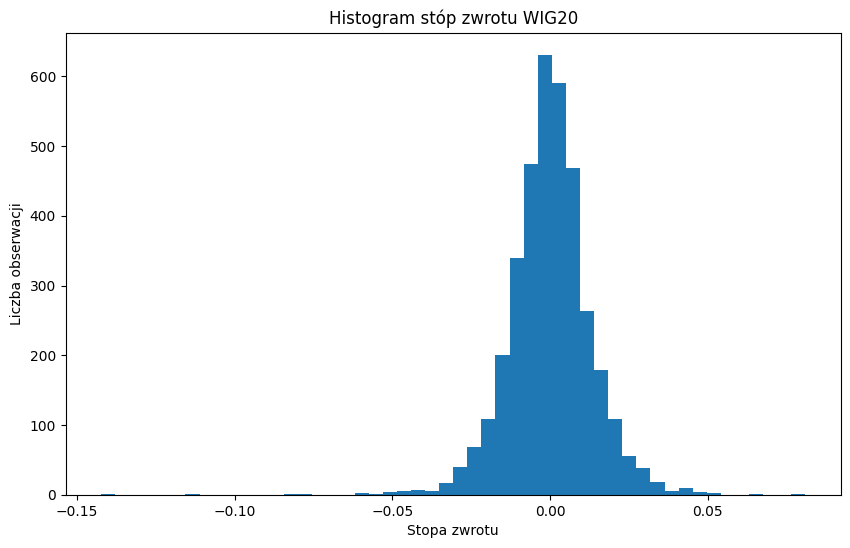

In [ ]:
#Histogram stóp zwrotu

plt.figure(figsize=(10,6))

plt.hist(
    dane_mag["stopa_zwrotu"],
    bins=50
)

plt.title("Histogram stóp zwrotu WIG20")
plt.xlabel("Stopa zwrotu")
plt.ylabel("Liczba obserwacji")

plt.savefig(
    f"{sciezka}/histogram_stop_zwrotu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Test normalności Jarque-Bera

from scipy.stats import jarque_bera

jb_test = jarque_bera(dane_mag["stopa_zwrotu"])

print("Statystyka JB:", jb_test.statistic)
print("p-value:", jb_test.pvalue)

Statystyka JB: 8697.561401854608
p-value: 0.0


<Figure size 1000x500 with 0 Axes>

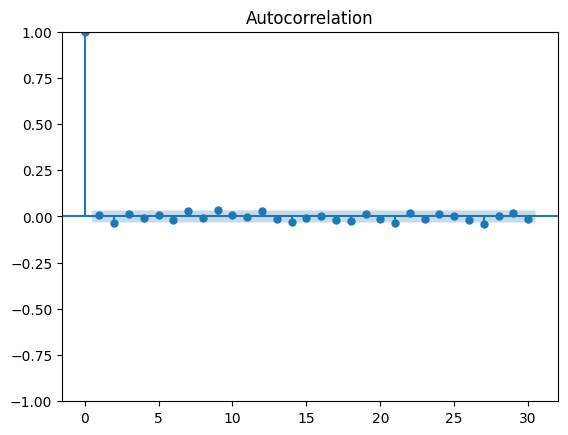

In [ ]:
#ACF — autokorelacja - czy obecne wartości zależą od poprzednich

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    dane_mag["stopa_zwrotu"].dropna(),
    lags=30
)

plt.savefig(
    f"{sciezka}/acf_stopy_zwrotu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x500 with 0 Axes>

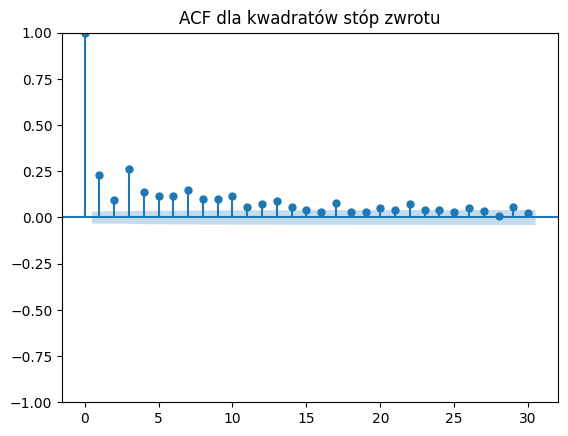

In [ ]:
#ACF dla kwadratów stóp zwrotu

plt.figure(figsize=(10,5))

plot_acf(
    dane_mag["stopa_zwrotu"].dropna()**2,
    lags=30
)

plt.title("ACF dla kwadratów stóp zwrotu")

plt.savefig(
    f"{sciezka}/acf_kwadraty_stop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Test ARCH

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(
    dane_mag["stopa_zwrotu"].dropna()
)

print("LM Stat:", arch_test[0])
print("p-value:", arch_test[1])

LM Stat: 463.8483916213835
p-value: 2.3189800884406814e-93


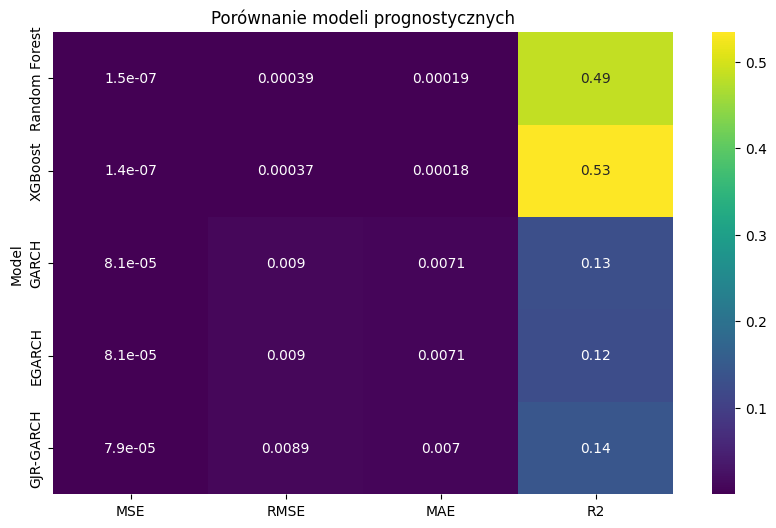

In [ ]:
#Heatmapa finalnych wyników modeli

import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    porownanie_final.set_index("Model"),
    annot=True,
    cmap="viridis"
)

plt.title("Porównanie modeli prognostycznych")

plt.savefig(
    f"{sciezka}/heatmapa_modeli.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
ranking = porownanie_final.sort_values(
    "RMSE"
)

ranking

,Model,MSE,RMSE,MAE,R2
1,XGBoost,1.400120e-07,0.000374,0.000184,0.534175
0,Random Forest,1.546821e-07,0.000393,0.000187,0.485367
4,GJR-GARCH,7.920678e-05,0.008900,0.006984,0.142066
2,GARCH,8.051275e-05,0.008973,0.007138,0.127921
3,EGARCH,8.088619e-05,0.008994,0.007136,0.123876


In [ ]:
#Deep Learning — model LSTM

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
dane_lstm = dane_mag[[
    "Zmienność",
    "VIX",
    "Inflacja"
]].copy()

dane_lstm.head()

,Zmienność,VIX,Inflacja
19,0.000067,22.59,2.9
20,0.000022,21.48,2.9
21,0.000016,21.60,2.9
22,0.001762,26.08,2.9
23,0.001624,26.11,2.9


In [ ]:
#skalowanie danych

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(dane_lstm)

scaled_data[:5]

array([[0.00331412, 0.1828688 , 0.225     ],
       [0.00109573, 0.16777702, 0.225     ],
       [0.00080231, 0.16940857, 0.225     ],
       [0.086847  , 0.23031951, 0.225     ],
       [0.08002624, 0.2307274 , 0.225     ]])

In [ ]:
#tworzenie sekwencji czasowych

X = []
y = []

window = 10

for i in range(window, len(scaled_data)):

    X.append(
        scaled_data[i-window:i]
    )

    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(3643, 10, 3)
(3643,)


In [ ]:
#train test/split

split = int(len(X) * 0.8)

X_train_lstm = X[:split]
X_test_lstm = X[split:]

y_train_lstm = y[:split]
y_test_lstm = y[split:]

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(2914, 10, 3)
(729, 10, 3)


In [ ]:
#budowa modelu LSTM

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        50,
        return_sequences=False,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,851 (42.39 KB)

 Trainable params: 10,851 (42.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#trening modelu

history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 7.0401e-04 - val_loss: 6.6716e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2874e-04 - val_loss: 1.6307e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1982e-04 - val_loss: 5.0687e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6927e-04 - val_loss: 1.4687e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2816e-04 - val_loss: 1.6025e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2914e-04 - val_loss: 1.6409e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3152e-04 - val_loss: 1.4677e-04
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3648e-04 - val_loss: 1.9301e-04
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3775e-04 - val_loss: 1.4767e-04
Epoch 10/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.2411e-04 - val_loss: 2.7057e-04
Epoch 11/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0506e-04 - val_lo

In [ ]:
#prognozy

y_pred_lstm = model_lstm.predict(X_test_lstm)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [ ]:
#odwrócenie skalowania

dummy_pred = np.zeros((len(y_pred_lstm), 3))
dummy_pred[:,0] = y_pred_lstm[:,0]

dummy_true = np.zeros((len(y_test_lstm), 3))
dummy_true[:,0] = y_test_lstm

y_pred_real = scaler.inverse_transform(dummy_pred)[:,0]
y_true_real = scaler.inverse_transform(dummy_true)[:,0]

In [ ]:
#ocena modelu

mse_lstm = mean_squared_error(
    y_true_real,
    y_pred_real
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    y_true_real,
    y_pred_real
)

r2_lstm = r2_score(
    y_true_real,
    y_pred_real
)

print("LSTM")
print("MSE:", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)
print("R2:", r2_lstm)

LSTM
MSE: 3.636811920237823e-07
RMSE: 0.0006030598577453008
MAE: 0.00024280190177638204
R2: 0.05843531694173554


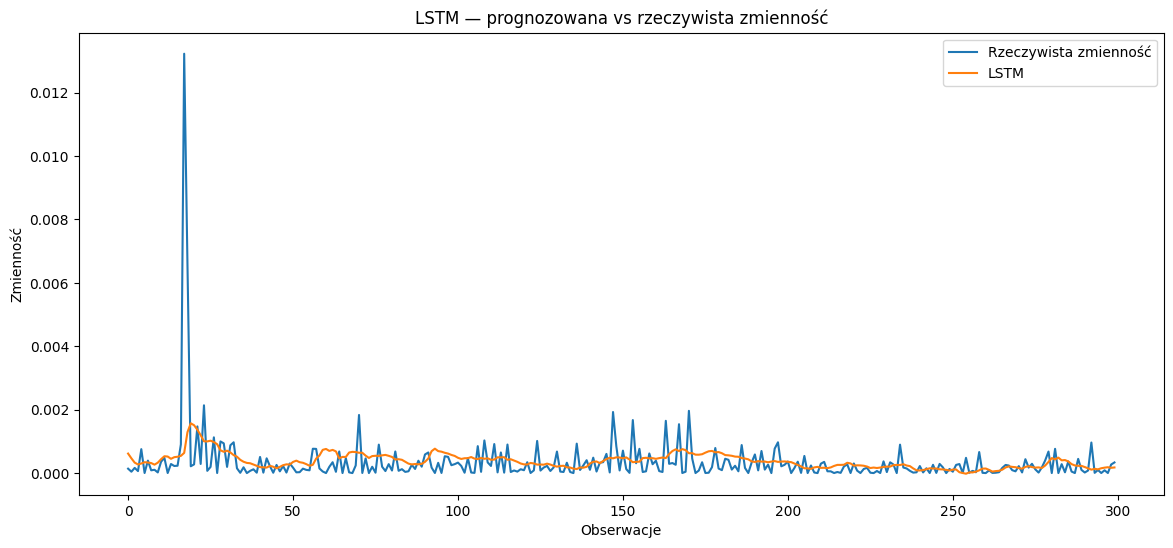

In [ ]:
#wykres LSTM

plt.figure(figsize=(14,6))

plt.plot(
    y_true_real[:300],
    label="Rzeczywista zmienność"
)

plt.plot(
    y_pred_real[:300],
    label="LSTM"
)

plt.title("LSTM — prognozowana vs rzeczywista zmienność")
plt.xlabel("Obserwacje")
plt.ylabel("Zmienność")

plt.legend()

plt.savefig(
    f"{sciezka}/lstm_prognozy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#finalna tabela v2

porownanie_final = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "GARCH",
        "EGARCH",
        "GJR-GARCH",
        "LSTM"
    ],
    "MSE": [
        mse_rf,
        mse_xgb,
        mse_garch,
        mse_egarch,
        mse_gjr,
        mse_lstm
    ],
    "RMSE": [
        rmse_rf,
        rmse_xgb,
        rmse_garch,
        rmse_egarch,
        rmse_gjr,
        rmse_lstm
    ],
    "MAE": [
        mae_rf,
        mae_xgb,
        mae_garch,
        mae_egarch,
        mae_gjr,
        mae_lstm
    ],
    "R2": [
        r2_rf,
        r2_xgb,
        r2_garch,
        r2_egarch,
        r2_gjr,
        r2_lstm
    ]
})

porownanie_final

,Model,MSE,RMSE,MAE,R2
0,Random Forest,1.546821e-07,0.000393,0.000187,0.485367
1,XGBoost,1.400120e-07,0.000374,0.000184,0.534175
2,GARCH,8.051275e-05,0.008973,0.007138,0.127921
3,EGARCH,8.088619e-05,0.008994,0.007136,0.123876
4,GJR-GARCH,7.920678e-05,0.008900,0.006984,0.142066
5,LSTM,3.636812e-07,0.000603,0.000243,0.058435


In [ ]:
#ranking finalny v2

ranking_final = porownanie_final.sort_values(
    "RMSE"
)

ranking_final

,Model,MSE,RMSE,MAE,R2
1,XGBoost,1.400120e-07,0.000374,0.000184,0.534175
0,Random Forest,1.546821e-07,0.000393,0.000187,0.485367
5,LSTM,3.636812e-07,0.000603,0.000243,0.058435
4,GJR-GARCH,7.920678e-05,0.008900,0.006984,0.142066
2,GARCH,8.051275e-05,0.008973,0.007138,0.127921
3,EGARCH,8.088619e-05,0.008994,0.007136,0.123876


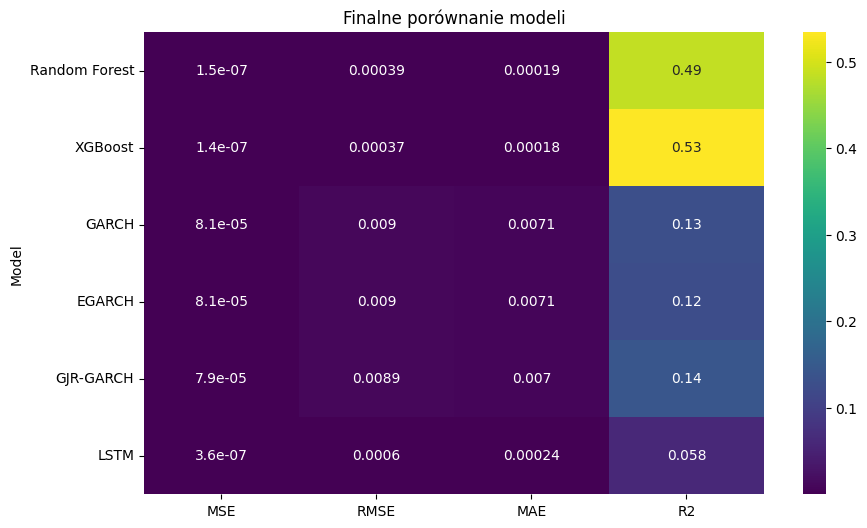

In [ ]:
#heatmapa finalna v2

plt.figure(figsize=(10,6))

sns.heatmap(
    porownanie_final.set_index("Model"),
    annot=True,
    cmap="viridis"
)

plt.title("Finalne porównanie modeli")

plt.savefig(
    f"{sciezka}/finalna_heatmapa.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()